# Implementing GPT model from scratch to generate text

In [2]:
! pip3 install torch
! pip3 install tiktoken

In [3]:
import torch
import torch.nn as nn
import tiktoken

torch.set_printoptions(sci_mode=False, precision=4)

# Feed forward with GeLU activation

In [4]:
class GELU(nn.Module):
  def __init__(self):
    super().__init__()

  def forward(self, x):
    return 0.5 * x * (1 + torch.tanh(
        torch.sqrt(torch.tensor(2 / torch.pi)) *
        (x + 0.044715 * torch.pow(x, 3))
    ))

In [5]:
class FeedForward(nn.Module):
  def __init__(self, cfg):
    super().__init__()
    self.layers = nn.Sequential(
        nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]), # Expansion
        GELU(), # Activation
        nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]), # Contraction
    )

  def forward(self, x):
    return self.layers(x)

## MultiHead Attention

In [6]:
class MultiHeadAttention(nn.Module):
  def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
    super().__init__()

    assert (d_out % num_heads) == 0, "d_out must be divisible by num_heads"

    self.d_out = d_out
    self.num_heads = num_heads
    # calculate individual head dimension according to d_out and no. of heads present
    self.head_dim = d_out // num_heads

    # random key,query,value initialization with d_in and d_out)
    self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.out_proj = nn.Linear(d_in, d_out) # Linear layer to combine head outputs
    self.dropout = nn.Dropout(dropout)

    self.register_buffer(
        "mask",
        torch.triu(torch.ones(context_length, context_length), diagonal=1)
    )

  def forward(self, x):
    b, num_tokens, d_in = x.shape # initialize (Batch, token_size, input_dimension)

    # keys, values queries (random of d_in,d_out(dimensions) multiplied with inputs)
    keys = self.W_key(x)
    queries = self.W_query(x)
    values = self.W_value(x)

    # convert of each head i.e d_out --> num_heads and head_dimension
    keys = keys.view(b, num_tokens, self.num_heads, self.head_dim)
    queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)
    values = values.view(b, num_tokens, self.num_heads, self.head_dim)

    # Group matrices by num_heads for parallel computation.

    #(b,num_tokens,num_heads,head_dim) --> (b, num_heads, num_tokens, head_dim)
    # (1,3,2,3) --> (1,2,3,3) (The positions 1 and 2 will be transposed)
    keys = keys.transpose(1,2)
    queries = queries.transpose(1,2)
    values = values.transpose(1,2)

    # now for each query we will do matmul with keys.
    # and for that we need to transpose the postion 2 and 3 of keys.
    # (b,num_heads,num_tokens,head_dim) * (b, num_heads, head_dim, num_tokens)
    #                                    |
    #                    (b,num_heads,num_tokens,num_tokens)
    attn_scores = queries @ keys.transpose(2,3)

    # masking
    mask_bool = self.mask.bool()[:num_tokens, :num_tokens]

    attn_scores = attn_scores.masked_fill(mask_bool, -torch.inf)

    # softmax with Sqrt of head_dim and dropout
    attn_weights = torch.softmax(attn_scores / self.head_dim**0.5, dim=-1)
    attn_weights = self.dropout(attn_weights)

    # calulate context vector with d_out as dimension preserved

    # (b,num_heads,num_tokens,num_tokens) * (b,num_heads,num_tokens,head_dim)
    #                                     |
    #                     (b,num_heads,num_tokens,head_dim)
    #                                     | (1,2) transpose
    #                     (b,num_tokens,num_heads,head_dim)
    context_vector = (attn_weights @ values).transpose(1,2)
    # now we can merge num_heads and head_dim easily to d_out.
    # we merge the num_heads and head_dim into single row giving d_out dimension.
    # (b,num_tokens,num_heads,head_dim) --> (b,num_tokens,d_out)
    # contiguous ensures that after reshaping the values stay in same block of memory.
    context_vector = context_vector.contiguous().view(b, num_tokens, self.d_out)
    context_vector = self.out_proj(context_vector)

    return context_vector

# **GPT architecture**

In [7]:
import torch
import torch.nn as nn

class GPTModel(nn.Module):
  def __init__(self, cfg):
    super().__init__()
    self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
    self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
    self.drop_emb = nn.Dropout(cfg["drop_rate"])

    # Use a placeholder for transformer block
    self.trf_blocks = nn.Sequential(
        *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])]
    )

    # Use a placeholder for layer norm
    self.final_norm = LayerNorm(cfg["emb_dim"])
    self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)

  def forward(self, in_idx):
    batch_size, seq_len = in_idx.shape
    tok_embeds = self.tok_emb(in_idx)
    pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
    x = tok_embeds + pos_embeds
    x = self.drop_emb(x)
    x = self.trf_blocks(x)
    x = self.final_norm(x)
    logits = self.out_head(x)
    return logits

class TransformerBlock(nn.Module):
  def __init__(self, cfg):
    super().__init__()
    self.att = MultiHeadAttention(
        d_in = cfg["emb_dim"],
        d_out = cfg["emb_dim"],
        context_length = cfg["context_length"],
        num_heads = cfg["n_heads"],
        dropout = cfg["drop_rate"],
        qkv_bias = cfg["qkv_bias"]
    )
    self.ff = FeedForward(cfg)
    self.norm1 = LayerNorm(cfg["emb_dim"])
    self.norm2 = LayerNorm(cfg["emb_dim"])
    self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

  def forward(self, x):
    # shortcut connection for attention block
    shortcut = x
    x = self.norm1(x) # normalization
    x = self.att(x) # attention
    x = self.drop_shortcut(x) # dropout
    x = x + shortcut # add the original input back

    # shortcut connection for feed forward block
    shortcut = x
    x = self.norm2(x) # normalization
    x = self.ff(x) # feed forward
    x = self.drop_shortcut(x) # dropout
    x = x + shortcut # add the original input back

    return x

class LayerNorm(nn.Module):
  def __init__(self, emb_dim):
    super().__init__()
    self.eps = 1e-5
    self.scale = nn.Parameter(torch.ones(emb_dim))
    self.shift = nn.Parameter(torch.zeros(emb_dim))

  def forward(self, x):
    mean = x.mean(dim=-1, keepdim=True)
    # if unbiased is 'True', it applied Bessels correction which is divide by n-1 for variance not by n.
    var = x.var(dim=-1, keepdim=True, unbiased=False)
    norm_x = (x - mean) / torch.sqrt(var + self.eps) # eps --> Epsilon is used to prevent division by 0 during normalization.
    return self.scale * norm_x + self.shift # scale and shifts are trainable parameters used to tweak norms.

# Using GPT to generate output

In [8]:
def generate_text_simple(model, idx, max_new_tokens, context_size):
  for _ in range(max_new_tokens):
    # crop current context if it exceeds the supported context size
    # e.g. if LLM supports only 5 tokens, and the context_size is 10
    # then only the last 5 tokens are used as context to predict next word
    idx_cond = idx[:, -context_size:]

    # Get the predictions
    with torch.no_grad():
      logits = model(idx_cond) # batch, n_tokens, vocab_size

    # Focus only on the last row from each batches
    # (batch, n_tokens, vocab_size) becomes (batch, vocab_size)
    logits = logits[:, -1, :]

    # Apply softmax to get the probabilities
    probas = torch.softmax(logits, dim=-1) # batch,vocab_size

    # Get the index with highest probability
    idx_next = torch.argmax(probas, dim=-1, keepdim=True) # (batch, 1)

    # Append sampled index to the running sequence.
    idx = torch.cat((idx, idx_next), dim=1) # (batch, n_tokens+1)

  return idx

In [9]:
GPT_CONFIG_124M = {
    "vocab_size": 50257, # vocabulary size
    "context_length": 256, # Shortened context length
    "emb_dim": 768, # embedding dimension
    "n_heads": 12,  # no. of attention heads
    "n_layers": 12, # no. of transformer layers
    "drop_rate": 0.1, # dropout rate
    "qkv_bias": False # query-key-value bias
}

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.eval(); # Disable dropout during inference

<h1> Decoding strategies to control randomness</h1>

In [27]:
model.to("cpu")
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

In [29]:
tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids("In the ancient cradle", tokenizer),
    max_new_tokens=25,
    context_size=GPT_CONFIG_124M["context_length"]
)

print("Output Text:\n", token_ids_to_text(token_ids, tokenizer))

Output Text:
 In the ancient cradle it, as the sun dipped behind the hills, painting the mist in hues of rose and lavender. She listened,


<h3> Temperature Scaling </h3>

To generate text with more variety, we replace the argmax with a function that samples from a probability distribution

In [30]:
vocab = {
"closer": 0,
"every": 1,
"effort": 2,
"forward": 3,
"inches": 4,
"moves": 5,
"pizza": 6,
"toward": 7,
"you": 8,
}

inverse_vocab = {v: k for k, v in vocab.items()}

In [32]:
# output will be of 9 as we have 9 vocabs
next_token_logits = torch.tensor(
[4.51, 0.89, -1.90, 6.75, 1.63, -1.62, -1.89, 6.28, 1.79]
)

In [34]:
probas = torch.softmax(next_token_logits, dim=0)
print(probas)
next_token_id = torch.argmax(probas).item()
print(inverse_vocab[next_token_id])

tensor([0.0609, 0.0016, 0.0001, 0.5721, 0.0034, 0.0001, 0.0001, 0.3576, 0.0040])
forward


In [35]:
# To implement a probabilistic sampling process, we can now replace argmax with
# the multinomial function in PyTorch
torch.manual_seed(123)
next_token_id = torch.multinomial(probas, num_samples=1).item()
print(inverse_vocab[next_token_id])

forward


The multinomial function samples the next token proportional to its probability score. In other words,
"forward" is still the most likely token and will be selected by multinomial most of
the time but not all the time. To illustrate this, let’s implement a function that repeats
this sampling 1,000 times

In [37]:
def print_sampled_tokens(probas):
    torch.manual_seed(123)
    sample = [torch.multinomial(probas, num_samples=1).item()
    for i in range(1_000)]
    sampled_ids = torch.bincount(torch.tensor(sample))
    for i, freq in enumerate(sampled_ids):
        print(f"{freq} x {inverse_vocab[i]}")
print_sampled_tokens(probas)

73 x closer
0 x every
0 x effort
582 x forward
2 x inches
0 x moves
0 x pizza
343 x toward


In [39]:
# Temperature scaling is just a fancy description for dividing the logits by a number greater than 0
def softmax_with_temperature(logits, temperature):
    scaled_logits = logits / temperature
    return torch.softmax(scaled_logits, dim=0)

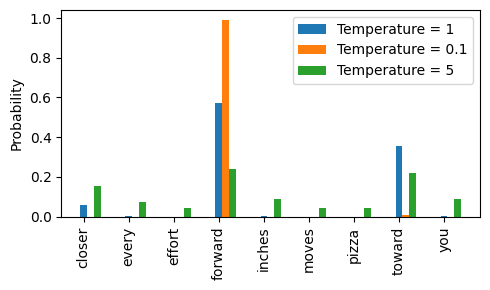

In [42]:
import matplotlib.pyplot as plt

temperatures = [1, 0.1, 5]
scaled_probas = [softmax_with_temperature(next_token_logits, T)
for T in temperatures]

# plotting
x = torch.arange(len(vocab))
bar_width = 0.15
fig, ax = plt.subplots(figsize=(5, 3))
for i, T in enumerate(temperatures):
    rects = ax.bar(x + i * bar_width, scaled_probas[i],
    bar_width, label=f'Temperature = {T}')
ax.set_ylabel('Probability')
ax.set_xticks(x)
ax.set_xticklabels(vocab.keys(), rotation=90)
ax.legend()
plt.tight_layout()
plt.show()

When we have low temperature value, then there is peak in probability distribution. This means that value is sharper for specific value.
When we have high temperature value, the probability distribution is flattened.